# Maze2D Large Maze Gallery

This notebook plots the original, non-discretized `LARGE_MAZE` and `LARGE_MAZE_EVAL` layouts directly from the Maze2D maze specifications.


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


In [2]:
MAZE_SPECS = {
    "LARGE_MAZE": "############\\#OOOO#OOOOO#\\#O##O#O#O#O#\\#OOOOOO#OOO#\\#O####O###O#\\#OO#O#OOOOO#\\##O#O#O#O###\\#OO#OOO#OGO#\\############",
    "LARGE_MAZE_EVAL": "############\\#OO#OOO#OGO#\\##O###O#O#O#\\#OO#O#OOOOO#\\#O##O#OO##O#\\#OOOOOO#OOO#\\#O##O#O#O###\\#OOOO#OOOOO#\\############",
}


def parse_maze_rows(maze_str):
    return maze_str.strip().split("\\")


def layout_from_spec(maze_str):
    rows = parse_maze_rows(maze_str)
    return {
        "height": len(rows),
        "width": len(rows[0]),
        "wall_cells": [
            [row, col]
            for row, row_text in enumerate(rows)
            for col, char in enumerate(row_text)
            if char == "#"
        ],
    }


def wall_rectangles_from_layout(layout):
    rectangles = []
    width = layout["width"]
    for row, col in layout["wall_cells"]:
        x = width - 1 - col
        y = row
        rectangles.append((x - 0.5, y - 0.5, 1.0, 1.0))
    return rectangles


def draw_maze(ax, layout, title):
    for x, y, w, h in wall_rectangles_from_layout(layout):
        ax.add_patch(Rectangle((x, y), w, h, facecolor="black", edgecolor="black", alpha=0.9))
    ax.set_xlim(-0.5, layout["width"] - 0.5)
    ax.set_ylim(-0.5, layout["height"] - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(layout["width"]))
    ax.set_yticks(range(layout["height"]))
    ax.grid(color="lightgray", linewidth=0.5)
    ax.set_xlabel("maze x")
    ax.set_ylabel("maze y")
    ax.set_title(title)


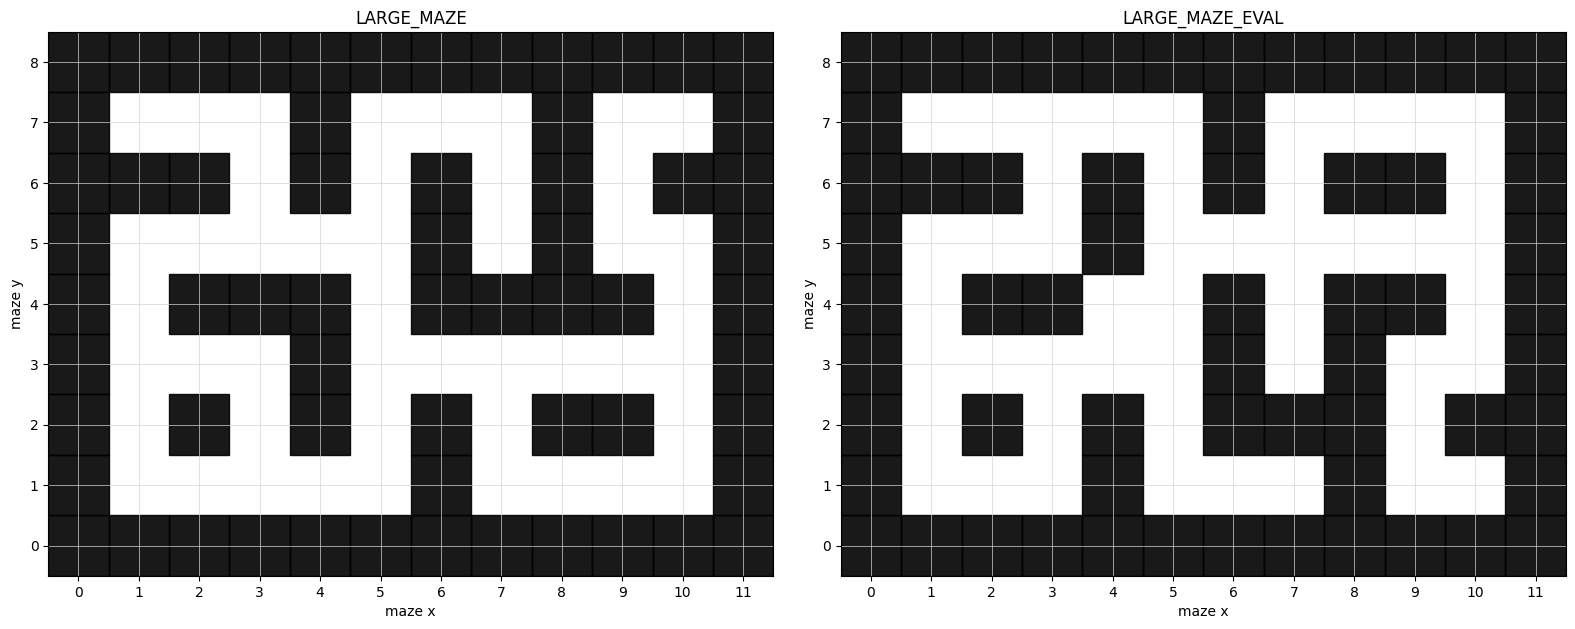

In [3]:
layouts = {name: layout_from_spec(spec) for name, spec in MAZE_SPECS.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (maze_name, layout) in zip(axes, layouts.items()):
    draw_maze(ax, layout, maze_name)

plt.tight_layout()
plt.show()
